# MC62 — Eddy Current Settling Analysis — `03_staircase_2Hz`

**Magnet**: MC62 (red bulk C-shaped dipole)  
**Machine**: LEAR antiproton decelerator, CERN  
**Test**: `03_staircase_2Hz` — streaming measurement (2026-02-16)  
**Rotation**: 2 Hz (120 rpm), 512 samples/turn, ~0.5 s per turn  
**Current cycle**: precycles + staircase 0→+200→0→−200→0 A in 20 A steps (1 A/s ramp rate)  
**Settling**: ~800 turns per plateau at 2 Hz = ~400 s per step  

---

This notebook studies eddy-current settling transients in B1, b2, and b3
at each staircase plateau. At 2 Hz rotation, one turn = 0.5 s, giving
excellent time resolution for fitting exponential decay constants.

**Comparison with 1 Hz measurement** (`02_staircase_without_shims`, 350 turns/plateau):
The eddy-current physics is the same, but this 2 Hz measurement has
2× the time resolution and 2× more turns per plateau, improving fits.

## 1. Configuration

In [ ]:
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
MEAS_DIR = Path(r"C:\Users\albellel\python-projects\rotating-coil-analyzer"
                r"\measurements\MC62_20260216_170750_staircase_2Hz\aperture1")

BIN_INTEGRAL = MEAS_DIR / "MC62_20260216_170750_staircase_2Hz_corr_sigs_Ap_1_SegIntegral.bin"

# Kn files — external calibration (same PCBs as previous MC62 tests)
KN_DIR      = Path(r"C:\Users\albellel\python-projects\rotating-coil-analyzer"
                   r"\measurements\2026_02_11_MC62\Kn values")
KN_INTEGRAL = KN_DIR / "Kn_R45_PCB_N1_0001_A_AC.txt"       # 30 harmonics

# ── Magnet & coil parameters ──────────────────────────────────────────────
MAGNET_ORDER     = 1        # dipole
R_REF            = 0.033    # reference radius [m]
SAMPLES_PER_TURN = 512      # encoder samples per revolution
RPM              = 120      # rotation speed
T_PER_TURN       = 60.0 / RPM  # 0.5 s per turn

# ── Pipeline options ──────────────────────────────────────────────────
# dit (di/dt correction) omitted: only relevant for per-turn parity
# against FFMM C++ on streaming data with current ramps.
OPTIONS    = ("dri", "rot", "cel", "fed")
DRIFT_MODE = "legacy"
MIN_B1_T   = 1e-6

# ── Sign convention ───────────────────────────────────────────────────
FLIP_FIELD_SIGN = True

# ── Settling analysis parameters ─────────────────────────────────────
N_SETTLED        = 100       # last N turns used as "settled" reference
N_SHOW_SETTLING  = 400       # turns to show in settling plots
MIN_I_FOR_FIT    = 10.0      # minimum |I_nom| for exponential fit [A]

# ── Plateau detection ─────────────────────────────────────────────────
# At 2 Hz with 1 A/s ramp, within-turn I variation is only ~0.5 A.
# Threshold 1.5 makes ALL turns pass as plateau. Use 0.5 to separate ramps.
PLATEAU_I_RANGE_MAX = 0.5    # plateau detection threshold
PLATEAU_MIN_LENGTH  = 50     # min turns per group (filters precycle fragments)
PLATEAU_MERGE_GAP   = 100    # merge consecutive groups at same I_nom if gap < this

print(f"MC62 Eddy Current Analysis — staircase_2Hz")
print(f"  Rotation: {RPM} rpm -> {T_PER_TURN:.2f} s/turn")
print(f"  Settled reference: last {N_SETTLED} turns ({N_SETTLED*T_PER_TURN:.0f} s)")
print(f"  Sign convention: {'Tesla columns sign-flipped' if FLIP_FIELD_SIGN else 'raw'}")
print(f"  Plateau threshold: {PLATEAU_I_RANGE_MAX} A, min_length={PLATEAU_MIN_LENGTH}")

## 2. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

%matplotlib widget

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 110,
})

from rotating_coil_analyzer.analysis.kn_pipeline import load_segment_kn_txt
from rotating_coil_analyzer.analysis.utility_functions import (
    compute_block_averaged_range,
    detect_plateau_turns,
    find_contiguous_groups,
    process_kn_pipeline,
    build_harmonic_rows,
    diagnose_cel_fed,
)
from rotating_coil_analyzer.ingest.channel_detect import robust_range

print("Imports ready.")

## 3. Load Data & Identify Staircase Plateaus

In [3]:
kn_integral = load_segment_kn_txt(str(KN_INTEGRAL))
print(f"Kn loaded: {len(kn_integral.orders)} harmonics")

# Load binary data
Ns = SAMPLES_PER_TURN
N_COLS = 4
raw = np.fromfile(str(BIN_INTEGRAL), dtype="<f8")
n_samples = len(raw) // N_COLS
n_turns = n_samples // Ns
n_keep = n_turns * Ns
raw = raw[:n_keep * N_COLS].reshape(n_keep, N_COLS)

t_all   = raw[:, 0].reshape(n_turns, Ns)
ch1_all = raw[:, 1].reshape(n_turns, Ns)
ch2_all = raw[:, 2].reshape(n_turns, Ns)
I_all   = raw[:, 3].reshape(n_turns, Ns)

# Channel detection
I_mean_quick = I_all.mean(axis=1)
best_turn = np.argmax(np.abs(I_mean_quick))
rr1 = robust_range(ch1_all[best_turn])
rr2 = robust_range(ch2_all[best_turn])
SWAP = rr2 > rr1
flux_abs = ch2_all if SWAP else ch1_all
flux_cmp = ch1_all if SWAP else ch2_all

print(f"Loaded: {n_turns} turns, time span: {t_all[0,0]:.1f}–{t_all[-1,-1]:.1f} s")
print(f"Channel detection: {'SWAP' if SWAP else 'no swap'}")

# Plateau detection
I_mean = I_all.mean(axis=1)
t_mean = t_all.mean(axis=1)
N_BLOCKS = 10
I_range, I_blocks = compute_block_averaged_range(I_all, Ns, N_BLOCKS)
plateau_info = detect_plateau_turns(I_blocks, I_mean, I_range, PLATEAU_I_RANGE_MAX)
is_plateau = plateau_info["is_plateau"]

# Identify plateau groups with merge step
plateau_groups_raw = find_contiguous_groups(is_plateau, min_length=PLATEAU_MIN_LENGTH)

group_info = []
for gi, (gs, ge) in enumerate(plateau_groups_raw):
    I_grp = I_mean[gs:ge+1]
    I_nom = round(I_grp.mean() / 20) * 20
    group_info.append({
        "group": gi, "start": gs, "end": ge,
        "n_turns": ge - gs + 1, "I_mean": I_grp.mean(), "I_nom": I_nom,
    })

# Merge consecutive groups at same I_nom with small gap
merged = [group_info[0].copy()]
for g in group_info[1:]:
    prev = merged[-1]
    gap = g["start"] - prev["end"]
    if g["I_nom"] == prev["I_nom"] and gap < PLATEAU_MERGE_GAP:
        prev["end"] = g["end"]
        prev["n_turns"] = prev["end"] - prev["start"] + 1
        I_slice = I_mean[prev["start"]:prev["end"]+1]
        prev["I_mean"] = I_slice.mean()
    else:
        merged.append(g.copy())

for i, g in enumerate(merged):
    g["group"] = i

# Identify staircase start (first long 0 A plateau)
staircase_start_group = None
for i, g in enumerate(merged):
    if abs(g["I_nom"]) < 2.0 and g["n_turns"] >= 500:
        staircase_start_group = i
        break

if staircase_start_group is None:
    staircase_start_group = 0
    staircase_start_turn = 0
    print("WARNING: could not identify staircase start, treating all data as staircase")
else:
    staircase_start_turn = merged[staircase_start_group]["start"]

# Build staircase run map
staircase_groups_list = [g for i, g in enumerate(merged) if i >= staircase_start_group]

run_info_list = []
for ri, g in enumerate(staircase_groups_list):
    run_info_list.append({
        "run_id": ri, "start": g["start"], "end": g["end"],
        "n_turns": g["n_turns"], "I_nom": g["I_nom"],
    })

# Branch direction
for i in range(len(run_info_list)):
    if i == 0:
        run_info_list[i]["branch"] = "ascending"
    elif run_info_list[i]["I_nom"] > run_info_list[i-1]["I_nom"]:
        run_info_list[i]["branch"] = "ascending"
    elif run_info_list[i]["I_nom"] < run_info_list[i-1]["I_nom"]:
        run_info_list[i]["branch"] = "descending"
    else:
        run_info_list[i]["branch"] = run_info_list[i-1]["branch"]

print(f"\nStaircase: {len(run_info_list)} plateaus (from turn {staircase_start_turn})")
for r in run_info_list:
    print(f"  Run {r['run_id']:02d}: I_nom={r['I_nom']:+4.0f} A, "
          f"{r['n_turns']:4d} turns, {r['branch']}")

Kn loaded: 30 harmonics
Loaded: 35828 turns, time span: 0.0–nan s
Channel detection: no swap



Staircase: 41 plateaus (from turn 3786)
  Run 00: I_nom=  +0 A,  750 turns, ascending
  Run 01: I_nom= +20 A,  726 turns, ascending
  Run 02: I_nom= +40 A,  745 turns, ascending
  Run 03: I_nom= +60 A,  749 turns, ascending
  Run 04: I_nom= +80 A,  738 turns, ascending
  Run 05: I_nom=+100 A,  745 turns, ascending
  Run 06: I_nom=+120 A,  748 turns, ascending
  Run 07: I_nom=+140 A,  744 turns, ascending
  Run 08: I_nom=+160 A,  747 turns, ascending
  Run 09: I_nom=+180 A,  746 turns, ascending
  Run 10: I_nom=+200 A,  743 turns, ascending
  Run 11: I_nom=+180 A,  742 turns, descending
  Run 12: I_nom=+160 A,  744 turns, descending
  Run 13: I_nom=+140 A,  746 turns, descending
  Run 14: I_nom=+120 A,  745 turns, descending
  Run 15: I_nom=+100 A,  742 turns, descending
  Run 16: I_nom= +80 A,  749 turns, descending
  Run 17: I_nom= +60 A,  746 turns, descending
  Run 18: I_nom= +40 A,  748 turns, descending
  Run 19: I_nom= +20 A,  702 turns, descending
  Run 20: I_nom=  +0 A,  712 t

## cel/fed Safety Diagnostic

Run `diagnose_cel_fed()` to check whether the centre-location +
feeddown correction is safe for this data.

In [ ]:
# Use a sample of turns for the diagnostic (e.g., first 100 turns)
_n_diag = min(100, flux_abs.shape[0])
diag = diagnose_cel_fed(
    flux_abs[:_n_diag], flux_cmp[:_n_diag],
    t_all[:_n_diag], I_all[:_n_diag],
    kn=kn_integral, r_ref=R_REF, magnet_order=MAGNET_ORDER,
)
print(f"cel/fed diagnostic: {diag.recommendation}")
print(f"  {diag.reason}")
_Bd = np.max(np.abs(diag.B_main_with_fed - diag.B_main_without_fed))
print(f"  B_main max |diff|: {_Bd:.4e} T")
del _n_diag, _Bd

## 4. Process All Staircase Turns Through Kn Pipeline

In [4]:
all_rows = []

for ri_info in run_info_list:
    gs = ri_info["start"]
    ge = ri_info["end"]
    idx = np.arange(gs, ge + 1)
    n = len(idx)

    try:
        result, C_merged, C_units, ok_main = process_kn_pipeline(
            flux_abs_turns=flux_abs[idx],
            flux_cmp_turns=flux_cmp[idx],
            t_turns=t_all[idx],
            I_turns=I_all[idx],
            kn=kn_integral,
            r_ref=R_REF,
            magnet_order=MAGNET_ORDER,
            options=OPTIONS,
            drift_mode=DRIFT_MODE,
            min_b1_T=MIN_B1_T,
            merge_mode="abs_upto_m_cmp_above",
        )

        extra = [{"run_id": ri_info["run_id"],
                  "I_nom": ri_info["I_nom"],
                  "branch": ri_info["branch"],
                  "turn_in_run": t}
                 for t in range(n)]
        rows = build_harmonic_rows(result, C_merged, C_units, ok_main,
                                   MAGNET_ORDER, extra)
        all_rows.extend(rows)
        n_ok = int(sum(ok_main))
        print(f"  Run {ri_info['run_id']:02d} "
              f"({ri_info['I_nom']:+4.0f} A, {ri_info['branch']:>10s}): "
              f"{n} turns, {n_ok} ok")
    except Exception as e:
        print(f"  Run {ri_info['run_id']:02d} ({ri_info['I_nom']:+4.0f} A): FAILED - {e}")

df = pd.DataFrame(all_rows)

# Sign convention
if FLIP_FIELD_SIGN:
    abs_cols = [c for c in df.columns if c.endswith("_T")]
    df[abs_cols] *= -1
    print("\n[Sign flip applied to Tesla columns]")

print(f"\nTotal: {len(df)} turn-level rows across "
      f"{df['run_id'].nunique()} runs")

  Run 00 (  +0 A,  ascending): 750 turns, 750 ok
  Run 01 ( +20 A,  ascending): 726 turns, 726 ok
  Run 02 ( +40 A,  ascending): 745 turns, 745 ok


  Run 03 ( +60 A,  ascending): 749 turns, 749 ok


  Run 04 ( +80 A,  ascending): 738 turns, 738 ok
  Run 05 (+100 A,  ascending): 745 turns, 745 ok
  Run 06 (+120 A,  ascending): 748 turns, 748 ok
  Run 07 (+140 A,  ascending): 744 turns, 744 ok


  Run 08 (+160 A,  ascending): 747 turns, 747 ok


  Run 09 (+180 A,  ascending): 746 turns, 746 ok
  Run 10 (+200 A,  ascending): 743 turns, 743 ok
  Run 11 (+180 A, descending): 742 turns, 742 ok
  Run 12 (+160 A, descending): 744 turns, 744 ok


...

  Run 23 ( -60 A, descending): 746 turns, 746 ok
  Run 24 ( -80 A, descending): 744 turns, 744 ok
  Run 25 (-100 A, descending): 745 turns, 745 ok
  Run 26 (-120 A, descending): 743 turns, 743 ok
  Run 27 (-140 A, descending): 745 turns, 745 ok


  Run 28 (-160 A, descending): 744 turns, 744 ok
  Run 29 (-180 A, descending): 744 turns, 744 ok
  Run 30 (-200 A, descending): 744 turns, 744 ok
  Run 31 (-180 A,  ascending): 743 turns, 743 ok


  Run 32 (-160 A,  ascending): 743 turns, 743 ok
  Run 33 (-140 A,  ascending): 744 turns, 744 ok
  Run 34 (-120 A,  ascending): 746 turns, 746 ok
  Run 35 (-100 A,  ascending): 744 turns, 744 ok


  Run 36 ( -80 A,  ascending): 744 turns, 744 ok
  Run 37 ( -60 A,  ascending): 744 turns, 744 ok
  Run 38 ( -40 A,  ascending): 746 turns, 746 ok
  Run 39 ( -20 A,  ascending): 744 turns, 744 ok
  Run 40 (  +0 A,  ascending): 764 turns, 763 ok



[Sign flip applied to Tesla columns]

Total: 30466 turn-level rows across 41 runs


## 5. Raw Settling Curves — B1 vs Turn Number

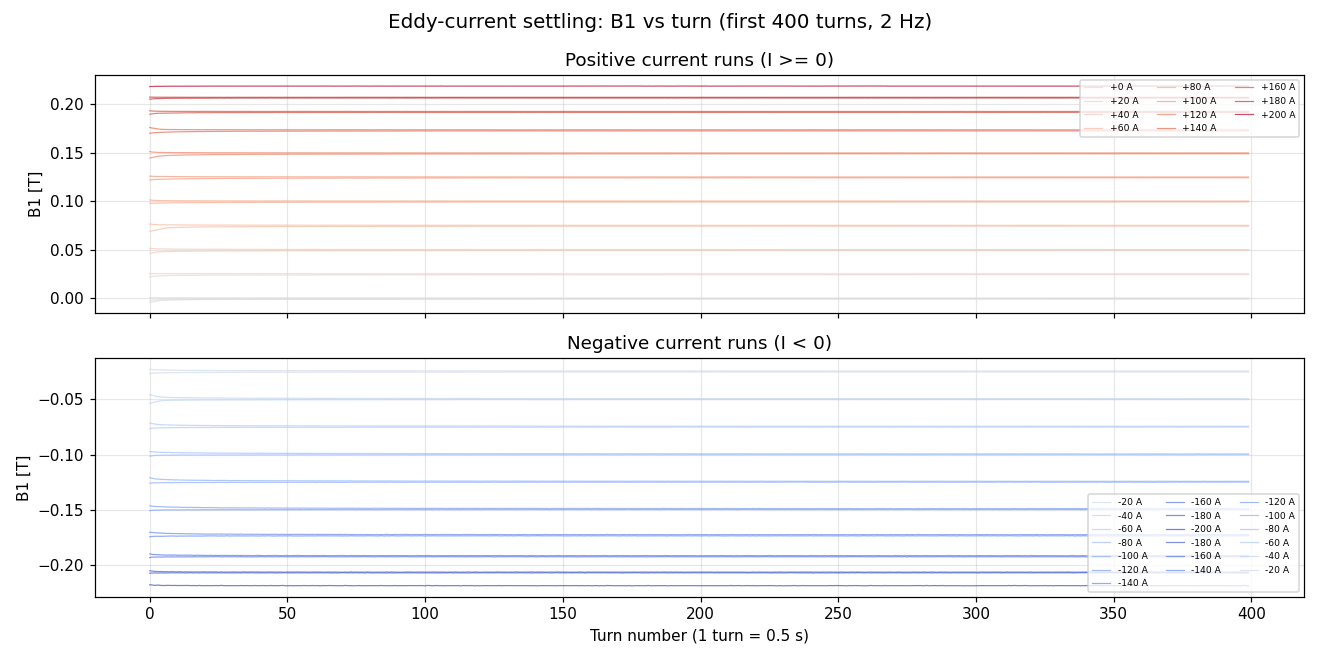

In [5]:
cmap = plt.cm.coolwarm
I_all_noms = sorted(df["I_nom"].unique())
norm_c = plt.Normalize(min(I_all_noms), max(I_all_noms))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Panel 1: positive current runs
ax = axes[0]
for run_id in sorted(df["run_id"].unique()):
    rdf = df[(df["run_id"] == run_id) & df["ok_main"]].sort_values("turn_in_run")
    if rdf.empty:
        continue
    I_nom = rdf["I_nom"].iloc[0]
    if I_nom < 0:
        continue
    first = rdf[rdf["turn_in_run"] < N_SHOW_SETTLING]
    if first.empty:
        continue
    color = cmap(norm_c(I_nom))
    ax.plot(first["turn_in_run"], first["B1_T"],
            "-", lw=0.8, color=color, alpha=0.7,
            label=f"{I_nom:+.0f} A" if run_id <= 10 else None)

ax.set_ylabel("B1 [T]")
ax.set_title("Positive current runs (I >= 0)")
ax.legend(fontsize=6, ncol=3, loc="upper right")

# Panel 2: negative current runs
ax = axes[1]
for run_id in sorted(df["run_id"].unique()):
    rdf = df[(df["run_id"] == run_id) & df["ok_main"]].sort_values("turn_in_run")
    if rdf.empty:
        continue
    I_nom = rdf["I_nom"].iloc[0]
    if I_nom >= 0:
        continue
    first = rdf[rdf["turn_in_run"] < N_SHOW_SETTLING]
    if first.empty:
        continue
    color = cmap(norm_c(I_nom))
    ax.plot(first["turn_in_run"], first["B1_T"],
            "-", lw=0.8, color=color, alpha=0.7,
            label=f"{I_nom:+.0f} A" if I_nom >= -200 and I_nom <= -20 else None)

ax.set_xlabel(f"Turn number (1 turn = {T_PER_TURN:.1f} s)")
ax.set_ylabel("B1 [T]")
ax.set_title("Negative current runs (I < 0)")
ax.legend(fontsize=6, ncol=3, loc="lower right")

fig.suptitle(f"Eddy-current settling: B1 vs turn (first {N_SHOW_SETTLING} turns, 2 Hz)",
             fontsize=13)
fig.tight_layout()
plt.show()

## 6. Exponential Fit Methodology

Model: $B_1(t) = B_{\infty} + A \cdot e^{-t/\tau}$

where $t$ is the turn number (time = turn × 0.5 s),
$B_{\infty}$ is the settled field, $A$ is the eddy-current amplitude,
and $\tau$ is the time constant in turns (multiply by 0.5 to get seconds).

## 7. Fit Tau for Each Plateau

In [6]:
def eddy_model(t, B_inf, A, tau):
    return B_inf + A * np.exp(-t / tau)

MIN_R2 = 0.5

fit_records = []

for run_id in sorted(df["run_id"].unique()):
    rdf = df[(df["run_id"] == run_id) & df["ok_main"]].sort_values("turn_in_run")
    if rdf.empty:
        continue

    I_nom = rdf["I_nom"].iloc[0]
    branch = rdf["branch"].iloc[0]

    if abs(I_nom) < MIN_I_FOR_FIT:
        continue

    turns = rdf["turn_in_run"].values.astype(float)
    B1 = rdf["B1_T"].values

    B1_inf_est = B1[-N_SETTLED:].mean()
    A_est = B1[0] - B1_inf_est
    tau_est = 40.0  # turns (= 20 s at 2 Hz)

    try:
        popt, pcov = curve_fit(
            eddy_model, turns, B1,
            p0=[B1_inf_est, A_est, tau_est],
            bounds=([-np.inf, -np.inf, 0.5], [np.inf, np.inf, 1000]),
            maxfev=10000,
        )
        perr = np.sqrt(np.diag(pcov))
        B_inf, A, tau = popt

        B1_pred = eddy_model(turns, *popt)
        ss_res = np.sum((B1 - B1_pred) ** 2)
        ss_tot = np.sum((B1 - B1.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

        fit_records.append({
            "run_id": run_id,
            "I_nom": I_nom,
            "abs_I": abs(I_nom),
            "branch": branch,
            "B1_inf": B_inf,
            "A": A,
            "tau_turns": tau,
            "tau_s": tau * T_PER_TURN,
            "B1_inf_err": perr[0],
            "A_err": perr[1],
            "tau_turns_err": perr[2],
            "tau_s_err": perr[2] * T_PER_TURN,
            "r2": r2,
            "n_turns": len(turns),
        })
    except (RuntimeError, ValueError) as e:
        print(f"  Run {run_id:02d} ({I_nom:+4.0f} A): fit failed - {e}")

df_fits_all = pd.DataFrame(fit_records)

print(f"Exponential fit results ({len(df_fits_all)} runs):")
print(f"{'Run':>4s} {'I [A]':>8s} {'Branch':>10s} {'tau [turns]':>11s} "
      f"{'tau [s]':>8s} {'A [T]':>12s} {'B1_inf [T]':>12s} {'R2':>8s} {'':>6s}")
print("-" * 90)
for _, r in df_fits_all.iterrows():
    flag = " " if r["r2"] >= MIN_R2 else " *OUT*"
    print(f"{r['run_id']:4.0f} {r['I_nom']:+8.1f} {r['branch']:>10s} "
          f"{r['tau_turns']:11.1f} {r['tau_s']:8.1f} "
          f"{r['A']:+12.6f} {r['B1_inf']:+12.6f} "
          f"{r['r2']:8.4f}{flag}")

df_fits = df_fits_all[df_fits_all["r2"] >= MIN_R2].copy()
n_removed = len(df_fits_all) - len(df_fits)
if n_removed > 0:
    out_ids = df_fits_all.loc[df_fits_all["r2"] < MIN_R2, "run_id"]
    print(f"\nRemoved {n_removed} outliers with R2 < {MIN_R2} "
          f"(runs {', '.join(str(int(r)) for r in out_ids)})")
print(f"Retained {len(df_fits)} good fits")

Exponential fit results (38 runs):
 Run    I [A]     Branch tau [turns]  tau [s]        A [T]   B1_inf [T]       R2       
------------------------------------------------------------------------------------------
   1    +20.0  ascending        33.3     16.6    -0.001329    +0.024549   0.9120 
   2    +40.0  ascending        26.4     13.2    -0.001786    +0.049499   0.8783 
   3    +60.0  ascending         9.4      4.7    -0.004813    +0.074413   0.8989 
   4    +80.0  ascending        60.8     30.4    -0.001059    +0.099381   0.9661 
   5   +100.0  ascending        44.7     22.4    -0.001528    +0.124213   0.9300 
   6   +120.0  ascending        21.4     10.7    -0.002935    +0.148865   0.9015 
   7   +140.0  ascending        20.0     10.0    -0.001828    +0.172405   0.9491 
   8   +160.0  ascending        10.1      5.0    -0.001403    +0.191410   0.8772 
   9   +180.0  ascending         8.3      4.2    -0.000918    +0.206232   0.7956 
  10   +200.0  ascending        11.4      5.7   

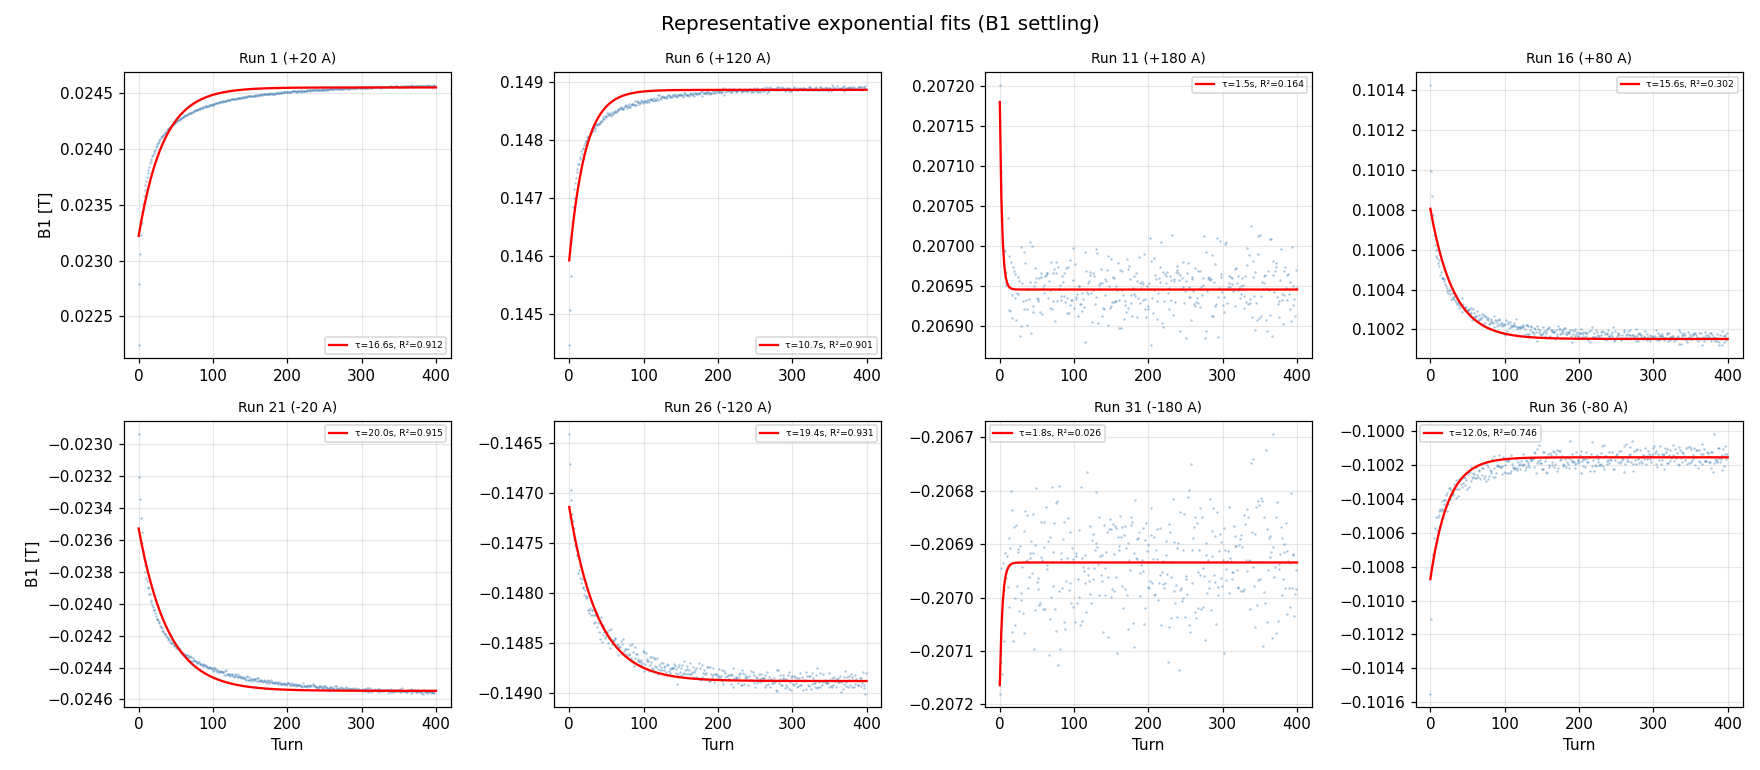

In [7]:
# Representative fits overlaid on data
show_runs = list(range(1, len(run_info_list), max(1, len(run_info_list)//8)))

n_show = min(8, len(show_runs))
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes_flat = axes.flatten()

for plot_i, run_id in enumerate(show_runs[:n_show]):
    ax = axes_flat[plot_i]
    rdf = df[(df["run_id"] == run_id) & df["ok_main"]].sort_values("turn_in_run")
    if rdf.empty:
        ax.set_visible(False)
        continue

    I_nom = rdf["I_nom"].iloc[0]
    turns = rdf["turn_in_run"].values.astype(float)
    B1 = rdf["B1_T"].values

    # Plot data (first N_SHOW_SETTLING turns)
    mask = turns < N_SHOW_SETTLING
    ax.plot(turns[mask], B1[mask], ".", ms=1, alpha=0.5, color="steelblue")

    # Overlay fit if available
    fit_row = df_fits_all[df_fits_all["run_id"] == run_id]
    if not fit_row.empty:
        fr = fit_row.iloc[0]
        t_fit = np.linspace(0, N_SHOW_SETTLING, 200)
        ax.plot(t_fit, eddy_model(t_fit, fr["B1_inf"], fr["A"], fr["tau_turns"]),
                "r-", lw=1.5,
                label=f"\u03c4={fr['tau_s']:.1f}s, R\u00b2={fr['r2']:.3f}")
        ax.legend(fontsize=6)

    ax.set_title(f"Run {run_id} ({I_nom:+.0f} A)", fontsize=9)
    ax.set_xlabel("Turn" if plot_i >= 4 else "")
    ax.set_ylabel("B1 [T]" if plot_i % 4 == 0 else "")

for i in range(n_show, len(axes_flat)):
    axes_flat[i].set_visible(False)

fig.suptitle("Representative exponential fits (B1 settling)", fontsize=13)
fig.tight_layout()
plt.show()

## 8. Tau vs Current — The Permeability Effect

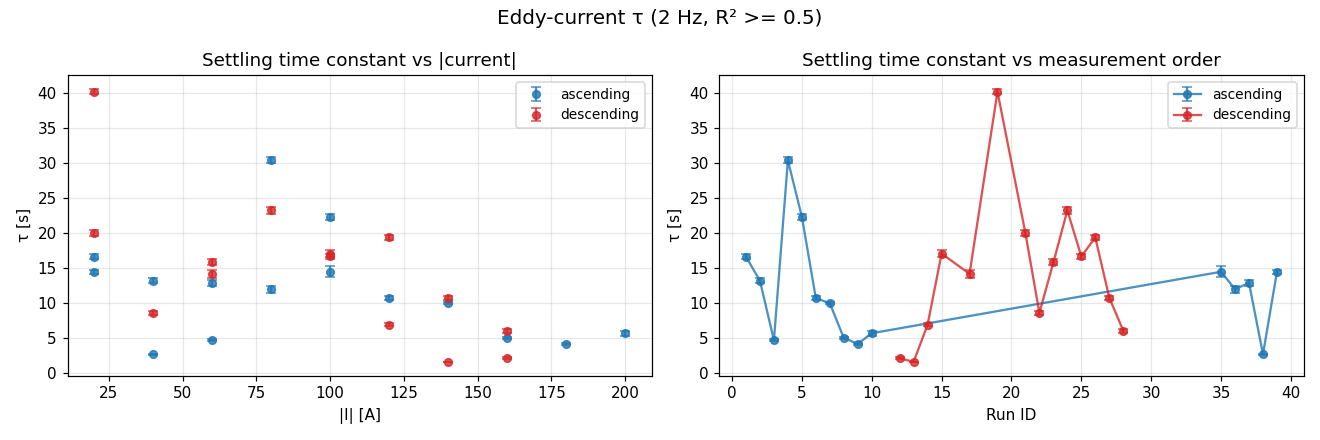


Tau statistics by |I| range (R2 >= 0.5, 29 runs):
  |I| in [ 10,  60) A: τ = 16.6 ± 11.9 s (N=7, range 2.7–40.2 s)
  |I| in [ 60, 120) A: τ = 16.7 ± 6.8 s (N=11, range 4.7–30.4 s)
  |I| in [120, 180) A: τ = 8.1 ± 5.5 s (N=9, range 1.6–19.4 s)
  |I| in [180, 210) A: τ = 4.9 ± 1.1 s (N=2, range 4.2–5.7 s)


In [8]:
branch_colors = {"ascending": "tab:blue", "descending": "tab:red"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) tau (seconds) vs |I|
ax = axes[0]
for branch, col in branch_colors.items():
    mask = df_fits["branch"] == branch
    if mask.any():
        ax.errorbar(df_fits.loc[mask, "abs_I"], df_fits.loc[mask, "tau_s"],
                    yerr=df_fits.loc[mask, "tau_s_err"],
                    fmt="o", color=col, ms=5, capsize=3, alpha=0.8,
                    label=branch)
ax.set_xlabel("|I| [A]")
ax.set_ylabel("\u03c4 [s]")
ax.set_title("Settling time constant vs |current|")
ax.legend(fontsize=9)

# (b) tau vs run order
ax = axes[1]
for branch, col in branch_colors.items():
    mask = df_fits["branch"] == branch
    if mask.any():
        ax.errorbar(df_fits.loc[mask, "run_id"], df_fits.loc[mask, "tau_s"],
                    yerr=df_fits.loc[mask, "tau_s_err"],
                    fmt="o-", color=col, ms=5, capsize=3, alpha=0.8,
                    label=branch)
ax.set_xlabel("Run ID")
ax.set_ylabel("\u03c4 [s]")
ax.set_title("Settling time constant vs measurement order")
ax.legend(fontsize=9)

fig.suptitle(f"Eddy-current \u03c4 (2 Hz, R\u00b2 >= {MIN_R2})", fontsize=13)
fig.tight_layout()
plt.show()

# Statistics by current range
print(f"\nTau statistics by |I| range (R2 >= {MIN_R2}, {len(df_fits)} runs):")
for lo, hi in [(10, 60), (60, 120), (120, 180), (180, 210)]:
    mask = (df_fits["abs_I"] >= lo) & (df_fits["abs_I"] < hi)
    if mask.any():
        tau_s = df_fits.loc[mask, "tau_s"]
        print(f"  |I| in [{lo:3d}, {hi:3d}) A: "
              f"\u03c4 = {tau_s.mean():.1f} \u00b1 {tau_s.std():.1f} s "
              f"(N={mask.sum()}, range {tau_s.min():.1f}\u2013{tau_s.max():.1f} s)")

## 9. Impact on Harmonics — Settling Bias in b2, b3

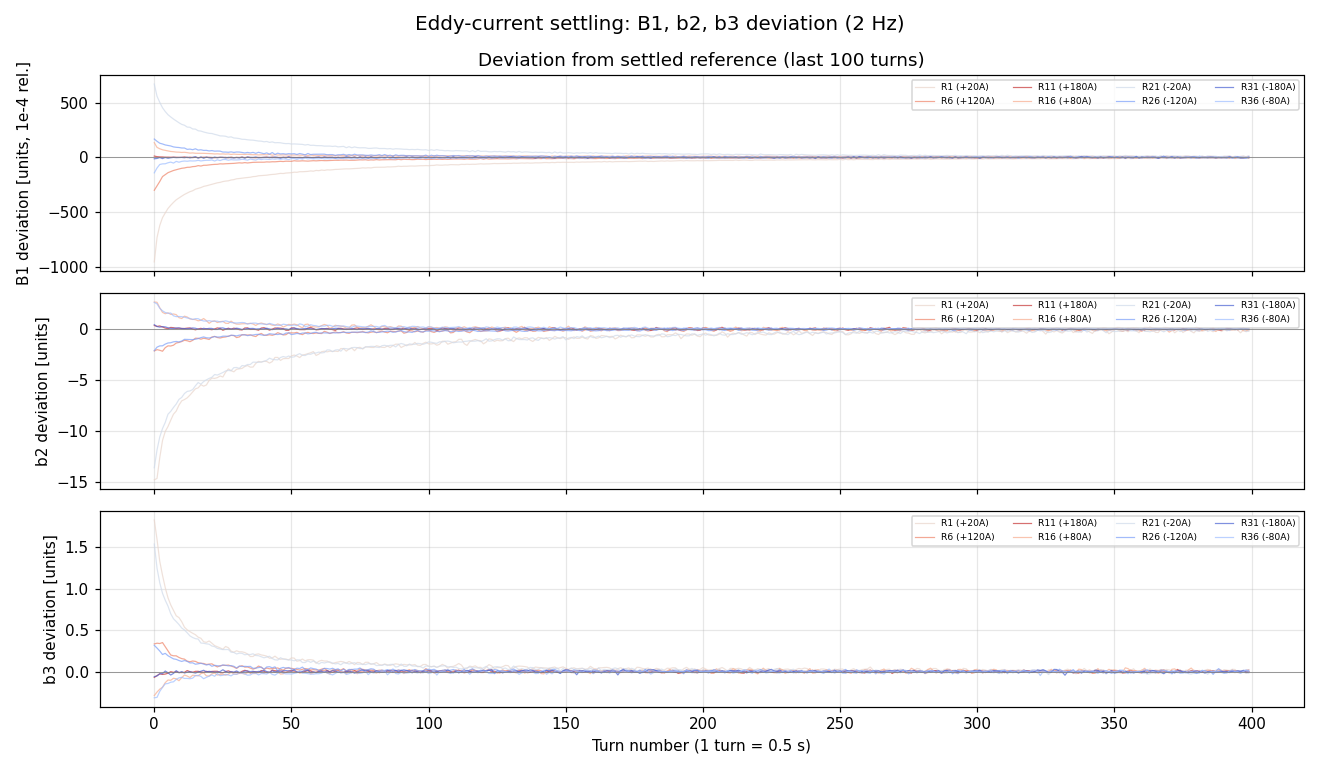

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

show_runs_dev = list(range(1, len(run_info_list), max(1, len(run_info_list)//8)))

for quantity, col_name, ax, ylabel in [
    ("B1", "B1_T", axes[0], "B1 deviation [units, 1e-4 rel.]"),
    ("b2", "b2_units", axes[1], "b2 deviation [units]"),
    ("b3", "b3_units", axes[2], "b3 deviation [units]"),
]:
    for run_id in show_runs_dev:
        rdf = df[(df["run_id"] == run_id) & df["ok_main"]].sort_values("turn_in_run")
        if rdf.empty or col_name not in rdf.columns:
            continue
        I_nom = rdf["I_nom"].iloc[0]
        if abs(I_nom) < MIN_I_FOR_FIT:
            continue

        vals = rdf[col_name].values
        turns = rdf["turn_in_run"].values

        ref = vals[-N_SETTLED:].mean()

        if quantity == "B1":
            if abs(ref) > 1e-10:
                dev = 1e4 * (vals - ref) / abs(ref)
            else:
                continue
        else:
            dev = vals - ref

        mask = turns < N_SHOW_SETTLING
        color = cmap(norm_c(I_nom))
        ax.plot(turns[mask], dev[mask], "-", lw=0.8, color=color, alpha=0.7,
                label=f"R{run_id} ({I_nom:+.0f}A)")

    ax.set_ylabel(ylabel)
    ax.axhline(0, color="gray", lw=0.5)
    ax.legend(fontsize=6, ncol=4, loc="upper right")

axes[0].set_title("Deviation from settled reference (last 100 turns)")
axes[-1].set_xlabel(f"Turn number (1 turn = {T_PER_TURN:.1f} s)")

fig.suptitle("Eddy-current settling: B1, b2, b3 deviation (2 Hz)", fontsize=13)
fig.tight_layout()
plt.show()

## 10. Sensitivity Study — N_LAST_TURNS

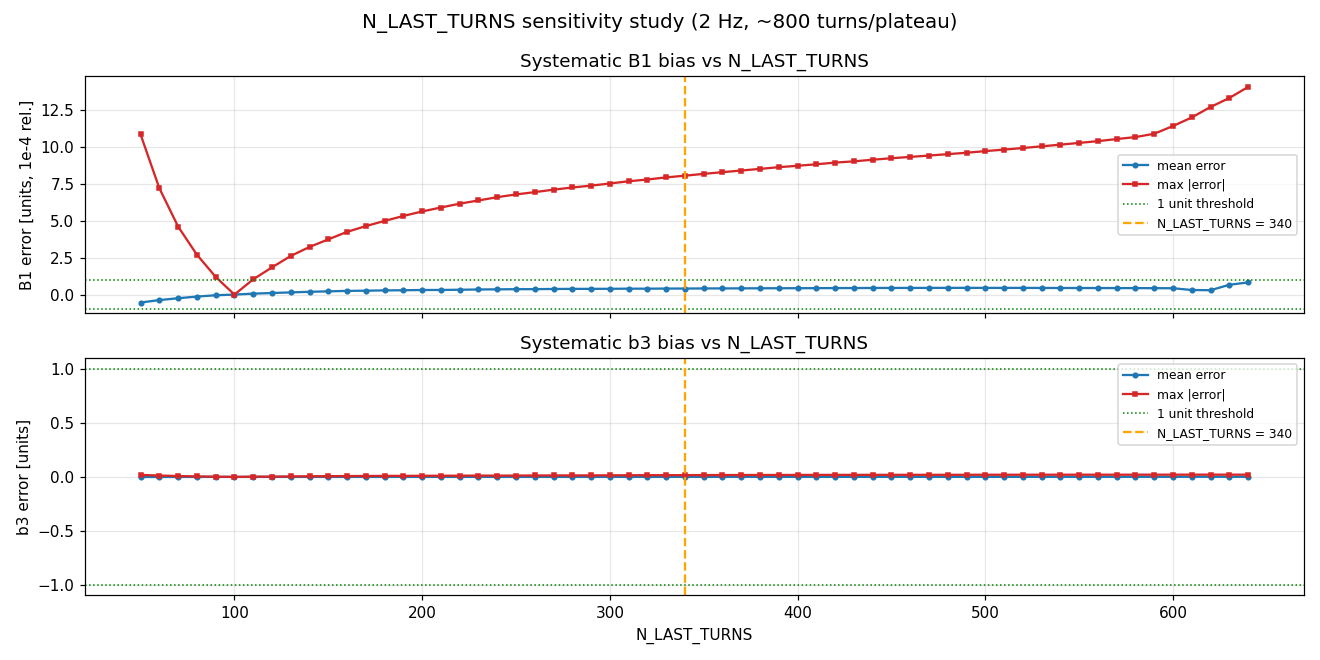


Key N_LAST_TURNS values:
  N_LAST_TURNS = 100: B1 max |error| = 0.00 units, b3 max |error| = 0.00 units
  N_LAST_TURNS = 200: B1 max |error| = 5.62 units, b3 max |error| = 0.01 units
  N_LAST_TURNS = 300: B1 max |error| = 7.51 units, b3 max |error| = 0.01 units
  N_LAST_TURNS = 340: B1 max |error| = 8.04 units, b3 max |error| = 0.02 units
  N_LAST_TURNS = 400: B1 max |error| = 8.71 units, b3 max |error| = 0.02 units
  N_LAST_TURNS = 500: B1 max |error| = 9.71 units, b3 max |error| = 0.02 units
  N_LAST_TURNS = 600: B1 max |error| = 11.40 units, b3 max |error| = 0.02 units


In [10]:
n_last_values = np.arange(50, 701, 10)
study_runs_ids = [r["run_id"] for r in run_info_list
                  if abs(r["I_nom"]) >= MIN_I_FOR_FIT]

results_sweep = []

for n_last in n_last_values:
    B1_errors = []
    b3_errors = []

    for run_id in study_runs_ids:
        rdf = df[(df["run_id"] == run_id) & df["ok_main"]].sort_values("turn_in_run")
        if len(rdf) < n_last + N_SETTLED:
            continue

        B1_ref = rdf["B1_T"].iloc[-N_SETTLED:].mean()
        B1_sel = rdf["B1_T"].iloc[-n_last:].mean()

        if abs(B1_ref) > 1e-10:
            B1_errors.append(1e4 * (B1_sel - B1_ref) / abs(B1_ref))

        if "b3_units" in rdf.columns:
            b3_ref = rdf["b3_units"].iloc[-N_SETTLED:].mean()
            b3_sel = rdf["b3_units"].iloc[-n_last:].mean()
            b3_errors.append(b3_sel - b3_ref)

    results_sweep.append({
        "n_last": n_last,
        "B1_mean_error": np.mean(B1_errors) if B1_errors else np.nan,
        "B1_max_error": np.max(np.abs(B1_errors)) if B1_errors else np.nan,
        "b3_mean_error": np.mean(b3_errors) if b3_errors else np.nan,
        "b3_max_error": np.max(np.abs(b3_errors)) if b3_errors else np.nan,
    })

df_sweep = pd.DataFrame(results_sweep)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax = axes[0]
ax.plot(df_sweep["n_last"], df_sweep["B1_mean_error"], "o-", ms=3,
        color="tab:blue", label="mean error")
ax.plot(df_sweep["n_last"], df_sweep["B1_max_error"], "s-", ms=3,
        color="tab:red", label="max |error|")
ax.axhline(1, color="green", ls=":", lw=1, label="1 unit threshold")
ax.axhline(-1, color="green", ls=":", lw=1)
ax.axvline(340, color="orange", ls="--", lw=1.5, label="N_LAST_TURNS = 340")
ax.set_ylabel("B1 error [units, 1e-4 rel.]")
ax.set_title("Systematic B1 bias vs N_LAST_TURNS")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(df_sweep["n_last"], df_sweep["b3_mean_error"], "o-", ms=3,
        color="tab:blue", label="mean error")
ax.plot(df_sweep["n_last"], df_sweep["b3_max_error"], "s-", ms=3,
        color="tab:red", label="max |error|")
ax.axhline(1, color="green", ls=":", lw=1, label="1 unit threshold")
ax.axhline(-1, color="green", ls=":", lw=1)
ax.axvline(340, color="orange", ls="--", lw=1.5, label="N_LAST_TURNS = 340")
ax.set_xlabel("N_LAST_TURNS")
ax.set_ylabel("b3 error [units]")
ax.set_title("Systematic b3 bias vs N_LAST_TURNS")
ax.legend(fontsize=8)

fig.suptitle("N_LAST_TURNS sensitivity study (2 Hz, ~800 turns/plateau)", fontsize=13)
fig.tight_layout()
plt.show()

# Key values
print("\nKey N_LAST_TURNS values:")
for n_check in [100, 200, 300, 340, 400, 500, 600]:
    row = df_sweep[df_sweep["n_last"] == n_check]
    if not row.empty:
        r = row.iloc[0]
        print(f"  N_LAST_TURNS = {n_check:3d}: "
              f"B1 max |error| = {r['B1_max_error']:.2f} units, "
              f"b3 max |error| = {r['b3_max_error']:.2f} units")

## 11. Precycle Region — Turn-by-Turn Current & Field

The precycles provide a view of the magnetic conditioning before the staircase.
Process a subset of the precycle turns for visualization.

Processing 2312 precycle plateau turns...


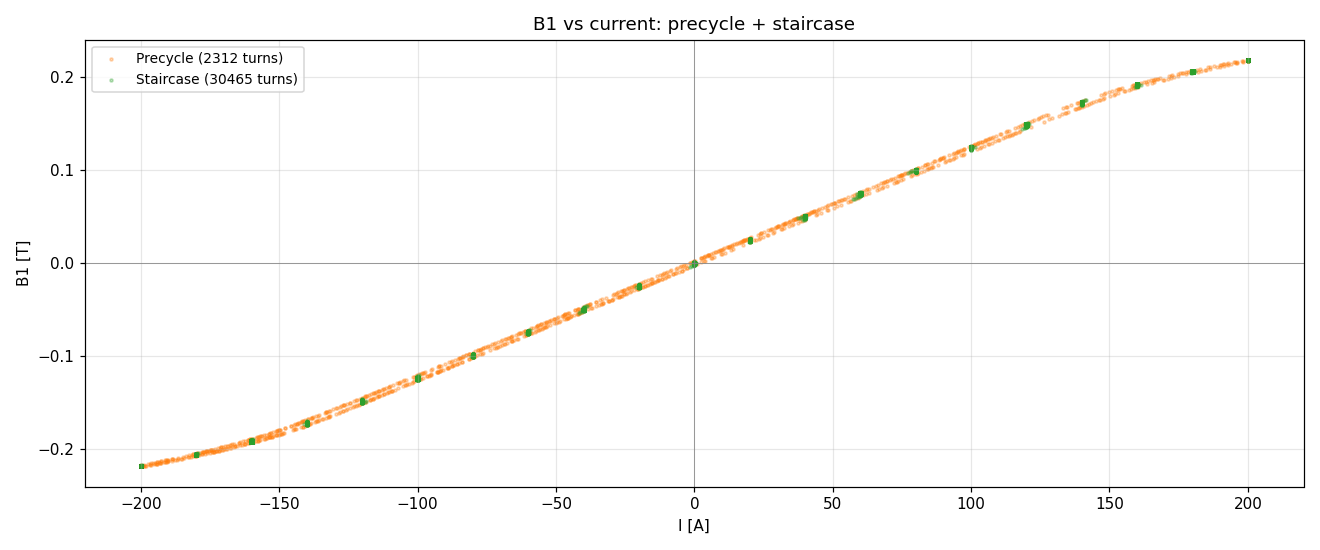

Precycle: 2312 turns, 2312 ok


In [11]:
# Process precycle turns (all plateau turns before staircase)
pre_plateau_mask = is_plateau & (np.arange(n_turns) < staircase_start_turn)
pre_idx = np.where(pre_plateau_mask)[0]

if len(pre_idx) > 0:
    print(f"Processing {len(pre_idx)} precycle plateau turns...")
    result_pre, C_pre, C_units_pre, ok_pre = process_kn_pipeline(
        flux_abs_turns=flux_abs[pre_idx],
        flux_cmp_turns=flux_cmp[pre_idx],
        t_turns=t_all[pre_idx],
        I_turns=I_all[pre_idx],
        kn=kn_integral,
        r_ref=R_REF,
        magnet_order=MAGNET_ORDER,
        options=OPTIONS,
        drift_mode=DRIFT_MODE,
        min_b1_T=MIN_B1_T,
    )

    extra_pre = [{"global_turn": int(t)} for t in pre_idx]
    rows_pre = build_harmonic_rows(result_pre, C_pre, C_units_pre, ok_pre,
                                    MAGNET_ORDER, extra_pre)
    df_pre = pd.DataFrame(rows_pre)

    if FLIP_FIELD_SIGN:
        abs_cols = [c for c in df_pre.columns if c.endswith("_T")]
        df_pre[abs_cols] *= -1

    # Plot precycle + staircase B1 vs current
    fig, ax = plt.subplots(figsize=(12, 5))

    # Precycle
    ok_pre_mask = df_pre["ok_main"].values
    ax.scatter(df_pre.loc[ok_pre_mask, "I_mean_A"],
              df_pre.loc[ok_pre_mask, "B1_T"],
              s=4, alpha=0.3, color="tab:orange", label=f"Precycle ({ok_pre_mask.sum()} turns)")

    # Staircase
    ok_stair = df["ok_main"].values
    ax.scatter(df.loc[ok_stair, "I_mean_A"],
              df.loc[ok_stair, "B1_T"],
              s=4, alpha=0.3, color="tab:green", label=f"Staircase ({ok_stair.sum()} turns)")

    ax.set_xlabel("I [A]")
    ax.set_ylabel("B1 [T]")
    ax.set_title("B1 vs current: precycle + staircase")
    ax.legend(fontsize=9)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    fig.tight_layout()
    plt.show()

    print(f"Precycle: {len(df_pre)} turns, {ok_pre_mask.sum()} ok")
else:
    print("No precycle plateau turns found.")

## 12. Summary & Recommendations

In [12]:
print("=" * 80)
print(f"  Eddy Current Settling — Summary (R2 >= {MIN_R2})")
print(f"  MC62 staircase_2Hz, 2 Hz rotation, 1 A/s ramp rate")
print("=" * 80)

if len(df_fits) > 0:
    print(f"\n  Good fits: {len(df_fits)} / {len(df_fits_all)} plateaus")
    print(f"  Tau range: {df_fits['tau_s'].min():.1f} – {df_fits['tau_s'].max():.1f} s")
    print(f"  Tau mean:  {df_fits['tau_s'].mean():.1f} \u00b1 {df_fits['tau_s'].std():.1f} s")

    # 5*tau settling rule
    tau_max_s = df_fits["tau_s"].max()
    settle_5tau_s = 5 * tau_max_s
    settle_5tau_turns = settle_5tau_s / T_PER_TURN
    print(f"\n  5\u00d7\u03c4_max = {settle_5tau_s:.0f} s = {settle_5tau_turns:.0f} turns (at 2 Hz)")
    print(f"  With ~{int(run_info_list[1]['n_turns'])} turns/plateau, safe N_LAST_TURNS = "
          f"{int(run_info_list[1]['n_turns']) - int(settle_5tau_turns)}")

    # Comparison with 1 Hz measurement
    print(f"\n  Note: Previous 02_staircase_without_shims (1 Hz, 350 turns/plateau)")
    print(f"  used N_LAST_TURNS=170. At 2 Hz with ~800 turns/plateau,")
    print(f"  N_LAST_TURNS=340 gives equivalent settling time.")

print(f"\n{'Run':>4s} {'I [A]':>8s} {'Branch':>10s} "
      f"{'\u03c4 [s]':>8s} {'A [\u00b5T]':>10s} {'B1_inf [T]':>12s} {'R\u00b2':>8s}")
print("-" * 70)
for _, r in df_fits.iterrows():
    print(f"{r['run_id']:4.0f} {r['I_nom']:+8.1f} {r['branch']:>10s} "
          f"{r['tau_s']:8.1f} {r['A']*1e6:+10.1f} {r['B1_inf']:+12.6f} "
          f"{r['r2']:8.4f}")

  Eddy Current Settling — Summary (R2 >= 0.5)
  MC62 staircase_2Hz, 2 Hz rotation, 1 A/s ramp rate

  Good fits: 29 / 38 plateaus
  Tau range: 1.6 – 40.2 s
  Tau mean:  13.2 ± 8.7 s

  5×τ_max = 201 s = 402 turns (at 2 Hz)
  With ~726 turns/plateau, safe N_LAST_TURNS = 324

  Note: Previous 02_staircase_without_shims (1 Hz, 350 turns/plateau)
  used N_LAST_TURNS=170. At 2 Hz with ~800 turns/plateau,
  N_LAST_TURNS=340 gives equivalent settling time.

 Run    I [A]     Branch    τ [s]     A [µT]   B1_inf [T]       R²
----------------------------------------------------------------------
   1    +20.0  ascending     16.6    -1329.3    +0.024549   0.9120
   2    +40.0  ascending     13.2    -1786.1    +0.049499   0.8783
   3    +60.0  ascending      4.7    -4813.4    +0.074413   0.8989
   4    +80.0  ascending     30.4    -1058.9    +0.099381   0.9661
   5   +100.0  ascending     22.4    -1528.2    +0.124213   0.9300
   6   +120.0  ascending     10.7    -2935.1    +0.148865   0.9015
   7 